**Assignment - EDA using Pandas**

***Instructions***
- Clone a copy of the assignment notebook in Google Colab.
- **Complete the tasks by filling in the code where indicated by TODO comments. Put each task in a new cell.**
- Run each cell to ensure your code works correctly.
- Pay attention to the output of each cell and interpret the results.
- For visualisation tasks, make sure to label axes, add titles, and choose appropriate colour schemes.
- After completing all tasks, review your findings and include notes of your insights gained from the EDA process as markdown notes for assessments.


In [10]:
# Titanic Dataset Exploratory Data Analysis

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype


In [4]:
# Task 1: Load the Titanic dataset
# TODO: Load the Titanic dataset from the following URL
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
titanic= pd.read_csv(url)

print(titanic.shape)
print(titanic.columns.tolist())
print(titanic.info())


(887, 8)
['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare']
<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    str    
 3   Sex                      887 non-null    str    
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), str(2)
memory usage: 81.6 KB
None


In [9]:
# Task 2: Inspect the data
# TODO: Display the first 5 rows of the dataset
print(titanic.head())

# TODO: Display the last 5 rows of the dataset
print(titanic.tail())

# TODO: Display the data 
print(titanic.dtypes)
# TODO: Display summary statistics of the numerical columns
print(titanic.describe())

   Survived  Pclass                                               Name  \
0         0       3                             Mr. Owen Harris Braund   
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2         1       3                              Miss. Laina Heikkinen   
3         1       1        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4         0       3                            Mr. William Henry Allen   

      Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare  
0    male  22.0                        1                        0   7.2500  
1  female  38.0                        1                        0  71.2833  
2  female  26.0                        0                        0   7.9250  
3  female  35.0                        1                        0  53.1000  
4    male  35.0                        0                        0   8.0500  
     Survived  Pclass                            Name     Sex   Age  \
882         0       2 

In [18]:
# Task 3: Clean and preprocess the data

# TODO: Create a new categorical feature 'PclassCategory' from 'Pclass'
titanic['PclassCategory']= titanic['Pclass'].map({
    1: "First",
    2: "Second",
    3: "Third"
})

# Convert object column to categorical dtype
pclass_type = CategoricalDtype(categories=['First', 'Second', 'Third'], ordered=True)
titanic['PclassCategory'] = titanic['Pclass'].map({1: 'First', 2: 'Second', 3: 'Third'}).astype(pclass_type)

#check it worked
print(titanic['PclassCategory'].dtype)
print(titanic.groupby('PclassCategory', observed=True)['Survived'].mean())


category
PclassCategory
First     0.629630
Second    0.472826
Third     0.244353
Name: Survived, dtype: float64


In [29]:
# TODO: Handle missing values in the 'Age' column (use mean age)
print(f'Missing Values in the Age:\n',titanic.isna().sum())

# TODO: Create a 'Family' feature by combining 'SibSp' and 'Parch'
titanic['Family'] = titanic['Siblings/Spouses Aboard'] + titanic['Parents/Children Aboard'] + 1

print("Cumulative Family Relatives:")
print(titanic['Family'].value_counts().sort_index())

Missing Values in the Age:
 Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
PclassCategory             0
Family                     0
dtype: int64
Cumulative Family Relatives:
Family
1     533
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


In [21]:
print(titanic.columns.tolist())
print(titanic.shape)

['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare', 'PclassCategory']
(887, 9)


In [47]:
# Task 4: Identify specific data points
# TODO: Find passengers with the highest fare
highest_fare_passengers = titanic[titanic['Fare'] == titanic['Fare'].max()]

# TODO: Find passengers with the largest family size
largest_family_passengers = titanic[titanic['Fare']== titanic['Fare'].max()]

print(highest_fare_passengers)
print(largest_family_passengers)


     Survived  Pclass                               Name     Sex   Age  \
257         1       1                    Miss. Anna Ward  female  35.0   
676         1       1  Mr. Thomas Drake Martinez Cardeza    male  36.0   
733         1       1              Mr. Gustave J Lesurer    male  35.0   

     Siblings/Spouses Aboard  Parents/Children Aboard      Fare  \
257                        0                        0  512.3292   
676                        0                        1  512.3292   
733                        0                        0  512.3292   

    PclassCategory  Family  
257          First       1  
676          First       2  
733          First       1  
     Survived  Pclass                               Name     Sex   Age  \
257         1       1                    Miss. Anna Ward  female  35.0   
676         1       1  Mr. Thomas Drake Martinez Cardeza    male  36.0   
733         1       1              Mr. Gustave J Lesurer    male  35.0   

     Siblings/Spouses

In [38]:
# Task 5: Demonstrate Pandas Series and DataFrame functionalities
# TODO: Create a Pandas Series of passenger names
names_series = titanic['Name']

print(type(names_series))
print(names_series.head())

# TODO: Create a DataFrame of passenger names and ages
names_ages_df = titanic[['Name', 'Age']]

print(type(names_ages_df))
print(names_ages_df.head())

# TODO: Slice the DataFrame to show only passengers older than 50
older_passengers = titanic[titanic['Age'] > 50]

print(older_passengers.shape)
print(older_passengers.head())

<class 'pandas.Series'>
0                               Mr. Owen Harris Braund
1    Mrs. John Bradley (Florence Briggs Thayer) Cum...
2                                Miss. Laina Heikkinen
3          Mrs. Jacques Heath (Lily May Peel) Futrelle
4                              Mr. William Henry Allen
Name: Name, dtype: str
<class 'pandas.DataFrame'>
                                                Name   Age
0                             Mr. Owen Harris Braund  22.0
1  Mrs. John Bradley (Florence Briggs Thayer) Cum...  38.0
2                              Miss. Laina Heikkinen  26.0
3        Mrs. Jacques Heath (Lily May Peel) Futrelle  35.0
4                            Mr. William Henry Allen  35.0
(72, 10)
    Survived  Pclass                            Name     Sex   Age  \
6          0       1          Mr. Timothy J McCarthy    male  54.0   
11         1       1         Miss. Elizabeth Bonnell  female  58.0   
15         1       2  Mrs. (Mary D Kingcome) Hewlett  female  55.0   
33      

In [39]:
# Task 6: Introduce multi-indexing
# TODO: Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
multi_index_df = titanic.groupby(['Sex', 'Pclass'])[['Survived', 'Age', 'Fare']].mean()

print(multi_index_df)

               Survived        Age        Fare
Sex    Pclass                                 
female 1       0.968085  35.255319  106.125798
       2       0.921053  28.980263   21.970121
       3       0.500000  22.135417   16.118810
male   1       0.368852  41.511639   67.226127
       2       0.157407  30.493796   19.741782
       3       0.137026  26.470612   12.695466


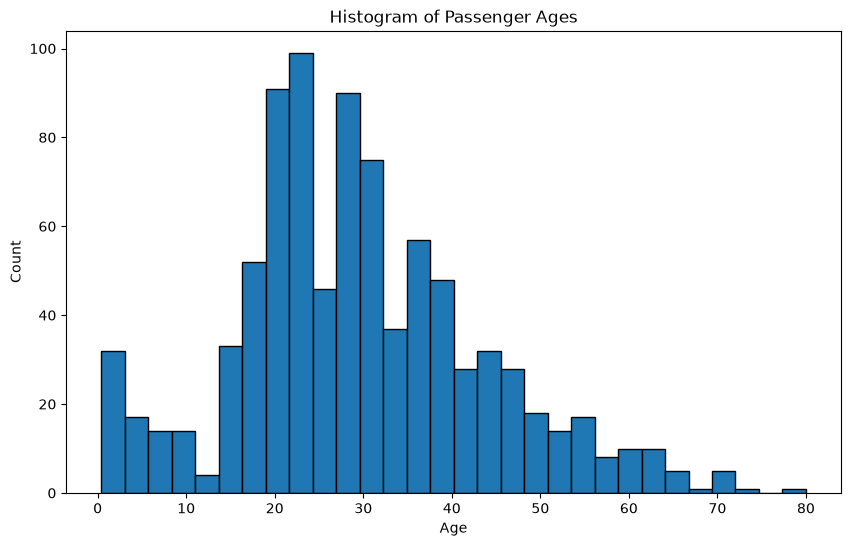

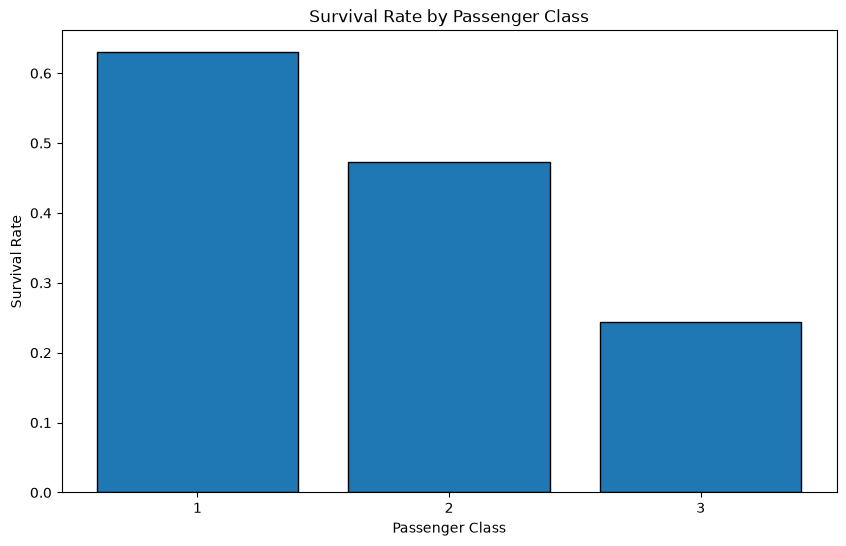

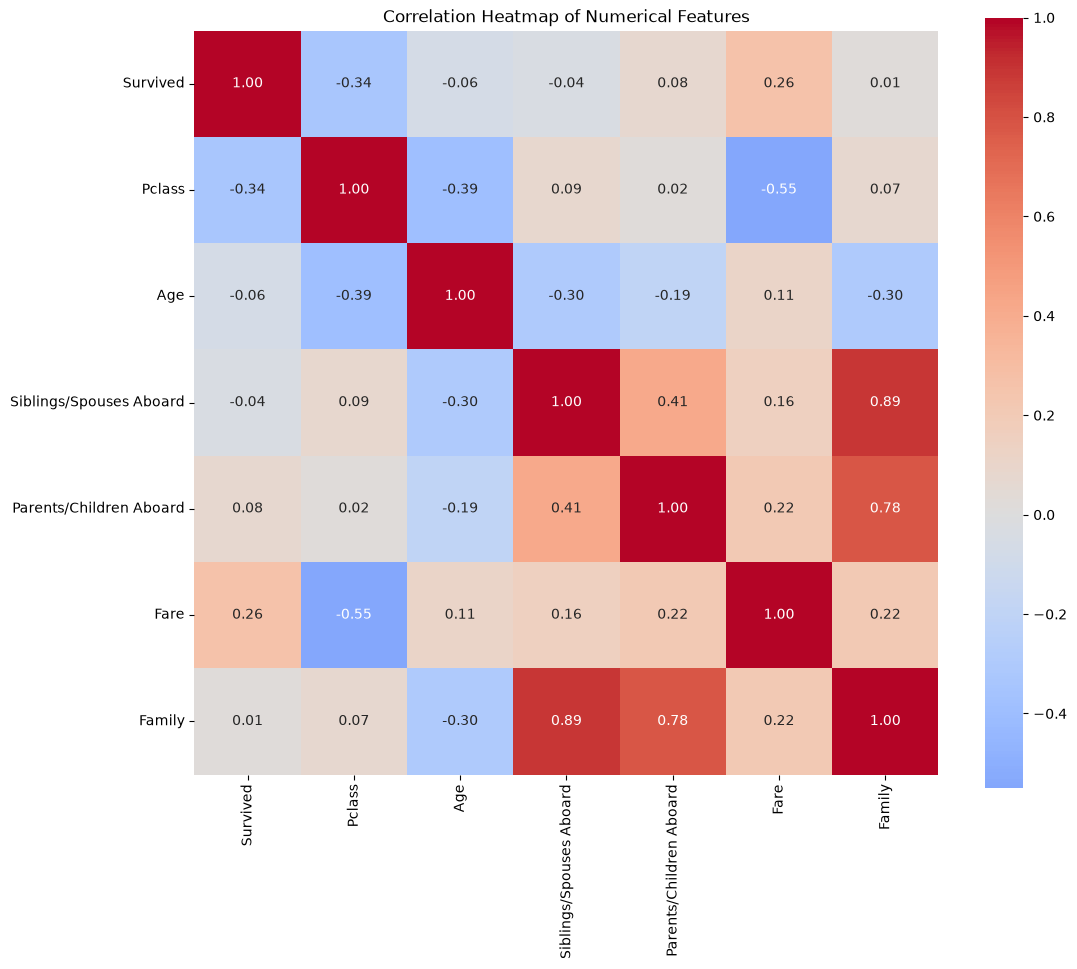

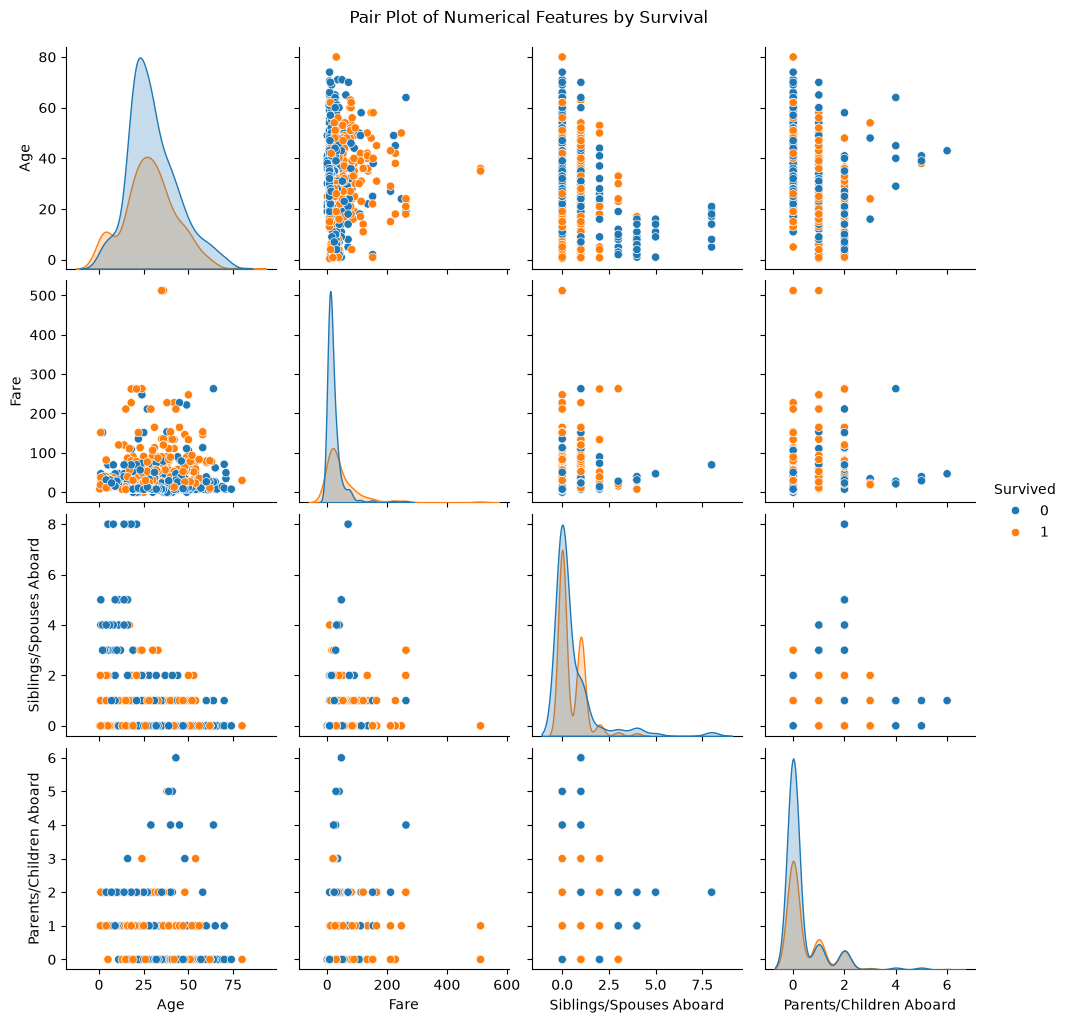

In [43]:
# Task 7: Visualizations
# TODO: Create a histogram of passenger ages
plt.figure(figsize=(10, 6))
plt.hist(titanic['Age'], bins=30, edgecolor='black')
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# TODO: Create a bar plot of survival rates by passenger class
survival_by_class = titanic.groupby('Pclass')['Survived'].mean()
plt.figure(figsize=(10, 6))
plt.bar(survival_by_class.index, survival_by_class.values, edgecolor='black')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks([1, 2, 3])
plt.show()

# TODO: Create a heatmap of correlation between numerical features
numeric_cols = ['Survived', 'Pclass', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare', 'Family']
corr = titanic[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# TODO: Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
sns.pairplot(
    titanic[['Age', 'Fare', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Survived']],
    hue='Survived',
    diag_kind='kde',
    height=2.5
)
plt.suptitle('Pair Plot of Numerical Features by Survival', y=1.02)
plt.show()


In [44]:
# Task 8: Analyze survival rates
# TODO: Calculate and display survival rates by sex
survival_by_sex = titanic.groupby('Sex')['Survived'].mean()

print(survival_by_sex)

# TODO: Calculate and display survival rates by passenger class
survival_by_class = titanic.groupby('Pclass')['Survived'].mean()

print(survival_by_class)

Sex
female    0.742038
male      0.190227
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.244353
Name: Survived, dtype: float64


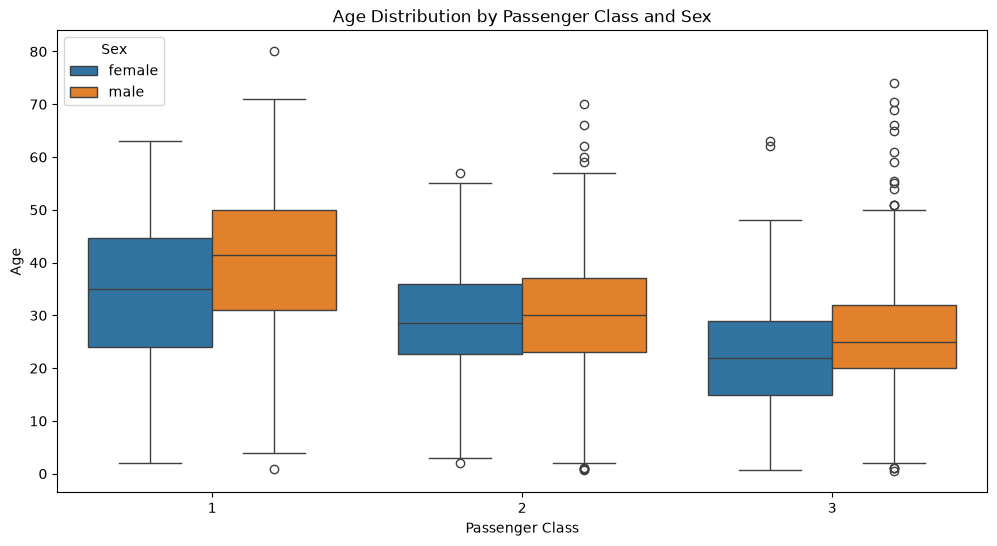

In [45]:
# Task 9: Analyze age distribution
# TODO: Create a box plot of age distribution by passenger class and sex
plt.figure(figsize=(12, 6))
sns.boxplot(data=titanic, x='Pclass', y='Age', hue='Sex')
plt.title('Age Distribution by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()

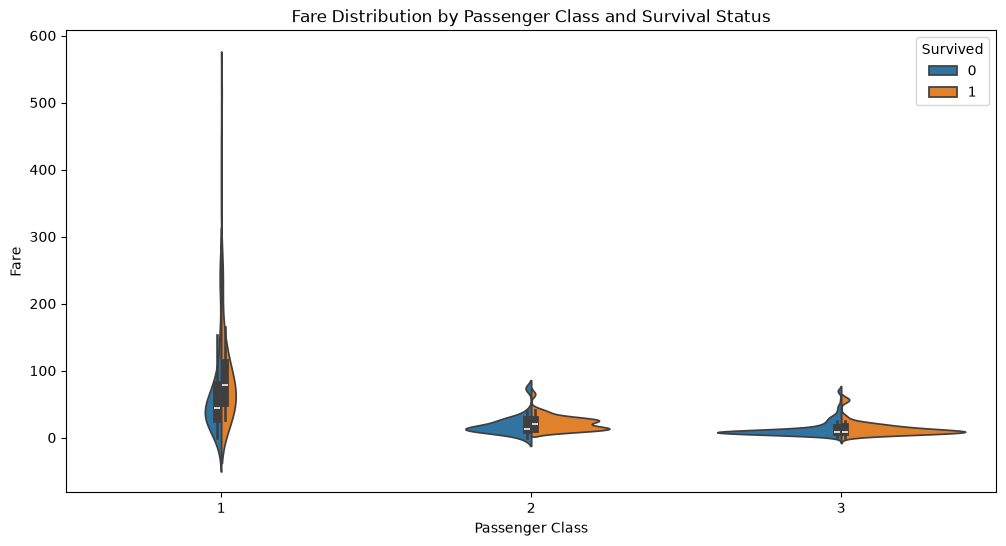

EDA tasks completed.


In [46]:
# Task 10: Analyze fare distribution

# TODO: Create a violin plot of fare distribution by passenger class and survival status
plt.figure(figsize=(12, 6))
sns.violinplot(data=titanic, x='Pclass', y='Fare', hue='Survived', split=True)
plt.title('Fare Distribution by Passenger Class and Survival Status')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

print("EDA tasks completed.")